<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_10.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_10.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 10:** Text Generation and Language Understanding using Transformer Models and Large Language Models (LLMs)

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will use Hugging Face **tokenizers** and **pipelines** to run several common transformer-based language tasks on small, CPU-friendly pretrained models: sentiment analysis, text generation, summarization, and zero-shot classification. You will measure the inference time of every task, compare them side by side, and inspect the qualitative outputs each pretrained model produces.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Use a Hugging Face tokenizer to inspect how raw text is converted into model input.
- Run pretrained transformer pipelines for sentiment analysis, text generation, summarization, and zero-shot classification.
- Measure and compare inference time across different transformer tasks.
- Interpret and critically evaluate qualitative outputs from pretrained language models.


## **Theory**

### Introduction

Transformers changed natural language processing by replacing recurrence with **self-attention**. Instead of reading text one token at a time like an RNN, transformer layers compare every token with every other token in parallel and learn which words are most relevant to the current context. Large Language Models (LLMs) are transformer-based systems trained on massive text corpora; even small, distilled pretrained models can perform several language tasks well when wrapped in a high-level pipeline interface.

### Mathematical Background

Self-attention computes weighted combinations of token embeddings. For queries $Q$, keys $K$, and values $V$, scaled dot-product attention is defined as

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

where $d_k$ is the dimensionality of the key vectors, and the $\sqrt{d_k}$ term keeps the softmax gradients well-scaled. **Multi-head attention** applies several such attention projections in parallel, letting the model focus on different relationships within the same sentence simultaneously. The resulting contextual embeddings are then passed to a task-specific head for classification, generation, or sequence-to-sequence output.

### Important Concepts

The basic transformer inference workflow is: load a tokenizer, convert text into token IDs, pass the tokens through a pretrained model, and decode the output back into text or labels. Hugging Face **pipelines** hide most of this boilerplate, exposing a single function call for common tasks. Because large models can be expensive to load and run, this notebook deliberately uses small or distilled models that are practical to run on a CPU.

- **Sentiment analysis** classifies text polarity (e.g. positive/negative).
- **Text generation** uses a causal language model to predict and sample the next tokens, extending a prompt.
- **Summarization** uses a sequence-to-sequence model to condense a longer passage into a shorter one.
- **Zero-shot classification** assigns a piece of text to one of several candidate labels without any task-specific fine-tuning, by reformulating classification as a natural language inference problem.

### Advantages and Applications

**Advantages**

- Transformers scale well, model long-range dependencies effectively, and transfer across many tasks from a single pretraining run.
- Pipelines make advanced NLP capabilities accessible with only a few lines of code.

**Disadvantages**

- Memory usage, latency, and the cost of loading pretrained weights can be significant, especially for larger models.
- Small, distilled models used for CPU-friendly demonstrations may produce less fluent or less accurate output than their full-sized counterparts.

**Applications**

Transformers and LLMs are used for translation, search, summarization, chat assistants, question answering, and many other language tasks across industry and research.

```mermaid
flowchart LR
    T[Input Text] --> U[Tokenizer]
    U --> M[Pretrained Transformer Model]
    M --> S1[Sentiment Head]
    M --> S2[Generation Head]
    M --> S3[Summarization Head]
    M --> S4[Zero-Shot / NLI Head]
    S1 --> O[Output: Label / Text / Summary / Ranking]
    S2 --> O
    S3 --> O
    S4 --> O
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- PyTorch (used here as the backend for Hugging Face Transformers)
- Hugging Face `transformers` (`pip install transformers torch`)
- NumPy, Pandas, Matplotlib

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

**Note:** Every pipeline in this notebook downloads its pretrained model weights from the Hugging Face Hub the first time it runs, so an active internet connection is required (Colab provides this automatically). Downloaded weights are cached locally, so subsequent runs are much faster.

## **Dataset Description**

This notebook uses short example sentences and prompts rather than a full training dataset, because the goal is to demonstrate **pretrained transformer inference**, not to train a model. The models themselves are already pretrained on large corpora and are accessed through the Hugging Face model hub.

- **Inputs:** sample review sentences, prompts, and a short paragraph.
- **Targets:** sentiment labels, generated text, a summary, and zero-shot class labels.
- **Source:** small, distilled Hugging Face pretrained models, chosen to be practical on CPU.
- **Reason for selection:** a lightweight, CPU-friendly demonstration of common transformer capabilities without requiring a GPU or a large dataset.

## **Experimental Procedure**

Follow the steps below in order:

1. Load a tokenizer and inspect how it tokenizes a sample sentence.
2. Run sentiment analysis on a couple of short text samples.
3. Generate text from a prompt using a small causal language model.
4. Summarize a short paragraph using a sequence-to-sequence model.
5. Run zero-shot classification on a sentence with several candidate labels.
6. Generate a response to your own prompt.
7. Compare the inference time of every task in one summary table and chart.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- What is the difference between a token and a word, based on what the tokenizer produced?
- Why does zero-shot classification not require any labeled training data for the target task?
- Which task had the longest inference time, and can you explain why, based on what that task's model has to compute (e.g. generating multiple tokens vs. a single classification)?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Change the generation prompt, the summarization text, or the zero-shot candidate labels, and observe how the outputs change.

**Note:** Every pipeline cell below downloads its pretrained model the first time it runs, so it requires an active internet connection (Colab provides this automatically).

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, pipeline

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [5]:
# Load a Tokenizer and Inspect Tokenized Input

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_text = "The lecture was clear, practical, and highly engaging."
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer(sample_text, return_tensors="pt")

print("Original text :", sample_text)
print("Tokens        :", tokens)
print("Token IDs     :", token_ids["input_ids"].tolist()[0])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Original text : The lecture was clear, practical, and highly engaging.
Tokens        : ['the', 'lecture', 'was', 'clear', ',', 'practical', ',', 'and', 'highly', 'engaging', '.']
Token IDs     : [101, 1996, 8835, 2001, 3154, 1010, 6742, 1010, 1998, 3811, 11973, 1012, 102]


In [6]:
# Task 1: Sentiment Analysis

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    framework="pt",
    device=-1,
)

sentiment_inputs = [
    "The lab manual is well organized and easy to follow.",
    "The explanation was confusing and incomplete.",
]

start = time.perf_counter()
sentiment_result = sentiment_pipeline(sentiment_inputs)
sentiment_time = time.perf_counter() - start

for text, result in zip(sentiment_inputs, sentiment_result):
    print(f"[{result['label']:8s} {result['score']:.3f}]  {text}")

print(f"\nInference time: {sentiment_time:.3f} seconds")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use cpu


[POSITIVE 1.000]  The lab manual is well organized and easy to follow.
[NEGATIVE 1.000]  The explanation was confusing and incomplete.

Inference time: 0.337 seconds


In [7]:
# Task 2: Text Generation

generation_pipeline = pipeline(
    "text-generation",
    model="sshleifer/tiny-gpt2",
    tokenizer="sshleifer/tiny-gpt2",
    framework="pt",
    device=-1,
)

start = time.perf_counter()
generated_text = generation_pipeline(
    "Artificial intelligence in the classroom",
    max_new_tokens=30,
    do_sample=True,
    temperature=0.8,
    num_return_sequences=1,
)
generation_time = time.perf_counter() - start

print(generated_text[0]["generated_text"])
print(f"\nInference time: {generation_time:.3f} seconds")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--sshleifer--tiny-gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.51M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial intelligence in the classroomoother pawn BrewmediatelymediatelySheratisf reborn vendors Jr Brew heir dispatch vendors circumcised trilogy ONE004hibitSher trilogy Daniel reborn hauled Habitimura credibility scalp Motorola Jr

Inference time: 0.697 seconds


In [14]:
# Task 3: Summarization

summarization_pipeline = pipeline(
    "summarization",
    model="google-t5/t5-small",
    tokenizer="google-t5/t5-small",
    framework="pt",
    device=-1,
)

long_text = (
    "Artificial intelligence is transforming engineering education by helping students analyze data, "
    "automate repetitive tasks, and explore large models that would otherwise be too expensive to train from scratch. "
    "In a laboratory setting, lightweight pretrained models are especially useful because they provide realistic outputs "
    "without requiring a large GPU."
)

start = time.perf_counter()

summary = summarization_pipeline(
    "summarize: " + long_text,
    max_length=40,
    min_length=15,
    do_sample=False
)

summarization_time = time.perf_counter() - start

print("Original text:\n", long_text)
print("\nSummary:\n", summary[0]["summary_text"])
print(f"\nInference time: {summarization_time:.3f} seconds")

config.json: 0.00B [00:00, ?B/s]

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--google-t5--t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Original text:
 Artificial intelligence is transforming engineering education by helping students analyze data, automate repetitive tasks, and explore large models that would otherwise be too expensive to train from scratch. In a laboratory setting, lightweight pretrained models are especially useful because they provide realistic outputs without requiring a large GPU.

Summary:
 lightweight pretrained models are especially useful because they provide realistic outputs without a large GPU .

Inference time: 1.835 seconds


In [9]:
# Task 4: Zero-Shot Classification

zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-small",
    tokenizer="cross-encoder/nli-deberta-v3-small",
    framework="pt",
    device=-1,
)

zero_shot_text = "The student wants to build a model that predicts future crop yield from weather data."
candidate_labels = ["computer vision", "natural language processing", "predictive modeling", "robotics"]

start = time.perf_counter()
zero_shot_result = zero_shot_pipeline(zero_shot_text, candidate_labels=candidate_labels)
zero_shot_time = time.perf_counter() - start

print("Text:", zero_shot_text)
for label, score in zip(zero_shot_result["labels"], zero_shot_result["scores"]):
    print(f"  {label:28s} {score:.3f}")

print(f"\nInference time: {zero_shot_time:.3f} seconds")

config.json: 0.00B [00:00, ?B/s]

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--cross-encoder--nli-deberta-v3-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Device set to use cpu


Text: The student wants to build a model that predicts future crop yield from weather data.
  predictive modeling          0.998
  natural language processing  0.001
  robotics                     0.001
  computer vision              0.001

Inference time: 1.737 seconds


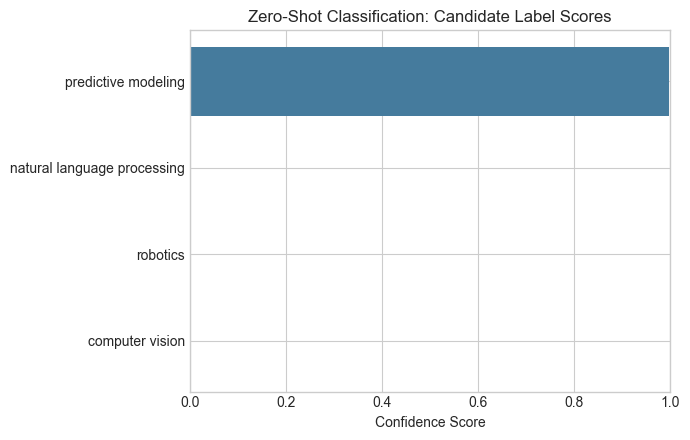

In [10]:
# Visualize Zero-Shot Classification Scores

plt.figure(figsize=(7, 4.5))

plt.barh(zero_shot_result["labels"][::-1], zero_shot_result["scores"][::-1], color="#457b9d")

plt.xlabel("Confidence Score")
plt.title("Zero-Shot Classification: Candidate Label Scores")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [11]:
# Task 5: Generate a Response to Your Own Prompt

prompt = "Write one sentence about why transformers are important for modern NLP."

start = time.perf_counter()
answer = generation_pipeline(prompt, max_new_tokens=25, do_sample=True, temperature=0.7)
prompt_time = time.perf_counter() - start

print("Prompt:", prompt)
print("Response:", answer[0]["generated_text"])
print(f"\nInference time: {prompt_time:.3f} seconds")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: Write one sentence about why transformers are important for modern NLP.
Response: Write one sentence about why transformers are important for modern NLP. Medic 236 rubbing Singapore Pocket�Gy workshopsshows Tre Pocket Pocket rubbing equate653obl 236 Bend448 incarcer skillet boils Late mutual653

Inference time: 0.375 seconds


In [12]:
# Compare Inference Time Across All Tasks

timing_df = pd.DataFrame([
    ["Sentiment Analysis", sentiment_time],
    ["Text Generation", generation_time],
    ["Summarization", summarization_time],
    ["Zero-Shot Classification", zero_shot_time],
    ["Custom Prompt Generation", prompt_time],
], columns=["Task", "Inference Time (s)"]).round(3)

timing_df

,Task,Inference Time (s)
0,Sentiment Analysis,0.337
1,Text Generation,0.697
2,Summarization,1.941
3,Zero-Shot Classification,1.737
4,Custom Prompt Generation,0.375


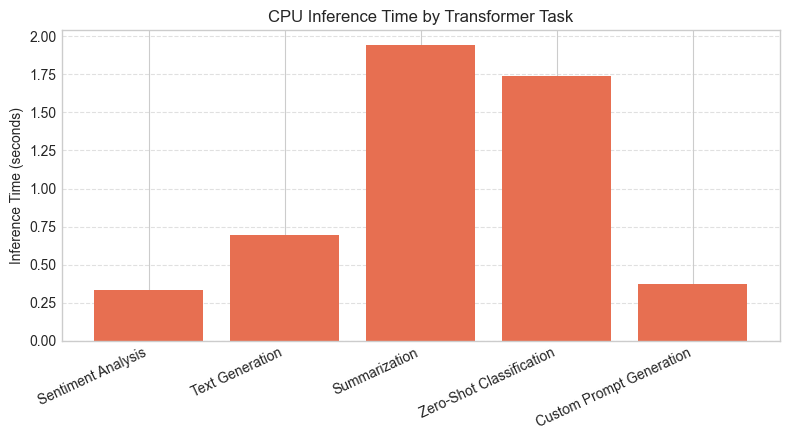

In [13]:
# Inference Time Comparison Chart

plt.figure(figsize=(8, 4.5))

plt.bar(timing_df["Task"], timing_df["Inference Time (s)"], color="#e76f51")

plt.ylabel("Inference Time (seconds)")
plt.title("CPU Inference Time by Transformer Task")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## **Expected Output**

After running all cells, the notebook should display:

- The tokenized form and token IDs of a sample sentence.
- Sentiment predictions (label and confidence score) for two sample sentences.
- A short generated continuation of a text-generation prompt.
- A summary of a longer paragraph.
- A ranked list of zero-shot classification labels with confidence scores, plus a bar chart.
- A generated response to a custom prompt.
- A table and bar chart comparing the inference time of every task.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Performance Evaluation**

For this LLM experiment, performance is largely qualitative and task-specific rather than a single accuracy number. Useful checks include: whether the sentiment output is sensible for each sentence, whether the generated text is fluent enough to plausibly continue the prompt, whether the summary preserves the main idea of the original paragraph, and whether the zero-shot label ranking makes intuitive sense. The inference-time comparison gives a simple, complementary sense of the computational cost of each task on CPU.

## **Discussion**

The pipeline interface makes transformer experimentation very accessible: a single function call handles tokenization, inference, and decoding for tasks that would otherwise require substantial boilerplate. Even though the models used here are small and distilled for CPU practicality, they already demonstrate the core capabilities of modern language systems — classification, generation, summarization, and zero-shot reasoning, all built on the same self-attention mechanism. The main limitation is that these pretrained models are still relatively heavy for repeated notebook execution, and their small size trades off fluency and accuracy compared to their full-sized counterparts. Text generation is typically the slowest task since it must compute a forward pass for every newly generated token, while sentiment analysis and zero-shot classification usually run in close to a single forward pass.

## **Viva Questions**

1. **Q:** What is self-attention?  
   **A:** A mechanism that lets each token in a sequence weigh the importance of every other token when building its contextual representation.

2. **Q:** Why are transformers often preferred over RNNs for many NLP tasks?  
   **A:** They process tokens in parallel rather than sequentially, and capture long-range dependencies more effectively.

3. **Q:** What does a tokenizer do?  
   **A:** It converts raw text into model-compatible token IDs, splitting words into subword units when necessary.

4. **Q:** What is a pipeline in Hugging Face Transformers?  
   **A:** A high-level wrapper that handles tokenization, model inference, and decoding for a specific task in a single function call.

5. **Q:** Why use tiny or distilled models in a lab notebook?  
   **A:** They are much faster to download and run on CPU, which is important for demonstrations without GPU access.

6. **Q:** What is zero-shot classification?  
   **A:** Classifying text into one of several candidate labels without any task-specific fine-tuning, typically by reframing the task as natural language inference.

7. **Q:** What is a causal language model?  
   **A:** A model that predicts the next token in a sequence given the tokens before it, which is the basis of text generation.

8. **Q:** What is summarization used for?  
   **A:** Condensing a longer text into a shorter version that preserves its main meaning.

9. **Q:** Why do transformer models require significant memory?  
   **A:** Because self-attention computations and the number of model parameters both scale with model size and sequence length.

10. **Q:** What is a practical use of LLMs in engineering education?  
    **A:** Assisting with explanation, content generation, information retrieval, and text analysis tasks.

## **Exercises**

Complete the following tasks after running the notebook:

1. Change the candidate labels in the zero-shot classifier and compare how the ranking changes.
2. Use a different prompt for text generation and compare the style and coherence of the output.
3. Replace the summarization model with another lightweight sequence-to-sequence model and compare the summaries.
4. Try a different sentiment analysis model from the Hugging Face Hub and compare its predictions with the one used here.
5. Vary the `temperature` parameter in text generation (e.g. 0.2 vs 1.0) and describe how the output changes.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including the tokenized sample, sentiment results, generated text, summary, and zero-shot ranking.
- The zero-shot classification bar chart and the inference-time comparison table and chart.
- Short discussion of which task was slowest and why, and how you judged output quality qualitatively.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
